In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
train = pd.read_csv("/content/Cap_Training_Data_2025.csv")
test = pd.read_csv("/content/Cap_Test_Data_2025.csv")
sample = pd.read_csv("/content/Cap_Sample_Submission_2025 (1).csv")

In [ ]:
print("Training shape:", train.shape)
print("Test shape:", test.shape)
print("Sample shape:", sample.shape)

Training shape: (53515, 17)
Test shape: (5615, 16)
Sample shape: (5615, 2)


In [ ]:
train.head()

,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
0,11100001,skoda,octavia,Ahmedabad,NaN,Second,1973.0,52,1964,147.0,compact,8,man,NaN,NaN,petrol,543764.25
1,11100002,fiat,panda,Ahmedabad,27750.0,Third,2021.0,4,1242,51.0,NaN,6,man,4.0,4.0,petrol,401819.25
2,11100003,bmw,x1,Hyderabad,46000.0,Third,2023.0,2,1995,105.0,NaN,7,auto,4.0,5.0,diesel,2392855.50
3,11100004,nissan,juke,Mumbai,43949.0,Third,2020.0,5,1618,140.0,NaN,7,man,4.0,5.0,petrol,958606.50
4,11100005,bmw,x5,Jaipur,59524.0,Fourth & Above,2021.0,4,2993,180.0,NaN,7,auto,4.0,5.0,diesel,3085561.50


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53515 entries, 0 to 53514
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   53515 non-null  int64  
 1   Maker                53515 non-null  object 
 2   model                53515 non-null  object 
 3   Location             53509 non-null  object 
 4   Distance             52304 non-null  float64
 5   Owner Type           53515 non-null  object 
 6   manufacture_year     53513 non-null  float64
 7   Age of car           53515 non-null  int64  
 8   engine_displacement  53515 non-null  int64  
 9   engine_power         52076 non-null  float64
 10  body_type            4136 non-null   object 
 11  Vroom Audit Rating   53515 non-null  int64  
 12  transmission         53515 non-null  object 
 13  door_count           45981 non-null  float64
 14  seat_count           45004 non-null  float64
 15  fuel_type            53515 non-null 

In [ ]:
train.describe()

,ID,Distance,manufacture_year,Age of car,engine_displacement,engine_power,Vroom Audit Rating,door_count,seat_count,Price
count,5.351500e+04,5.230400e+04,53513.000000,53515.000000,53515.000000,52076.000000,53515.000000,45981.000000,45004.000000,5.351500e+04
mean,1.112676e+07,9.454626e+04,2019.408032,5.591946,1904.049014,100.448345,5.998374,3.973011,4.886099,1.098084e+06
std,1.544859e+04,2.755617e+05,4.650367,4.650281,1496.564596,45.330622,1.418336,0.740659,0.564332,8.441565e+05
min,1.110000e+07,0.000000e+00,1943.000000,0.000000,14.000000,10.000000,4.000000,1.000000,1.000000,3.000000e+00
25%,1.111338e+07,1.549000e+04,2017.000000,2.000000,1395.000000,73.000000,5.000000,4.000000,5.000000,5.051812e+05
50%,1.112676e+07,6.552000e+04,2020.000000,5.000000,1896.000000,91.000000,6.000000,4.000000,5.000000,8.854552e+05
75%,1.114014e+07,1.356410e+05,2023.000000,8.000000,1995.000000,125.000000,7.000000,4.000000,5.000000,1.477829e+06
max,1.115352e+07,9.899800e+06,2025.000000,82.000000,32000.000000,896.000000,8.000000,6.000000,9.000000,2.212078e+07


In [ ]:
train.columns

Index(['ID', 'Maker', 'model', 'Location', 'Distance ', 'Owner Type',
       'manufacture_year', 'Age of car', 'engine_displacement', 'engine_power',
       'body_type', 'Vroom Audit Rating', 'transmission', 'door_count',
       'seat_count', 'fuel_type', 'Price'],
      dtype='object')

In [ ]:
train.isnull().sum()

,0
ID,0
Maker,0
model,0
Location,6
Distance,1211
Owner Type,0
manufacture_year,2
Age of car,0
engine_displacement,0
engine_power,1439


In [ ]:
missing = train.isnull().sum()

missing_percentage = (
    missing / len(train) * 100
).sort_values(ascending=False)

missing_percentage

,0
body_type,92.271326
seat_count,15.903952
door_count,14.078296
engine_power,2.688966
Distance,2.262917
Location,0.011212
manufacture_year,0.003737
ID,0.000000
model,0.000000
engine_displacement,0.000000


In [ ]:
train.duplicated().sum()

np.int64(0)

In [ ]:
train = train.drop_duplicates()

In [ ]:
train["Price"].describe()

,Price
count,5.351500e+04
mean,1.098084e+06
std,8.441565e+05
min,3.000000e+00
25%,5.051812e+05
50%,8.854552e+05
75%,1.477829e+06
max,2.212078e+07


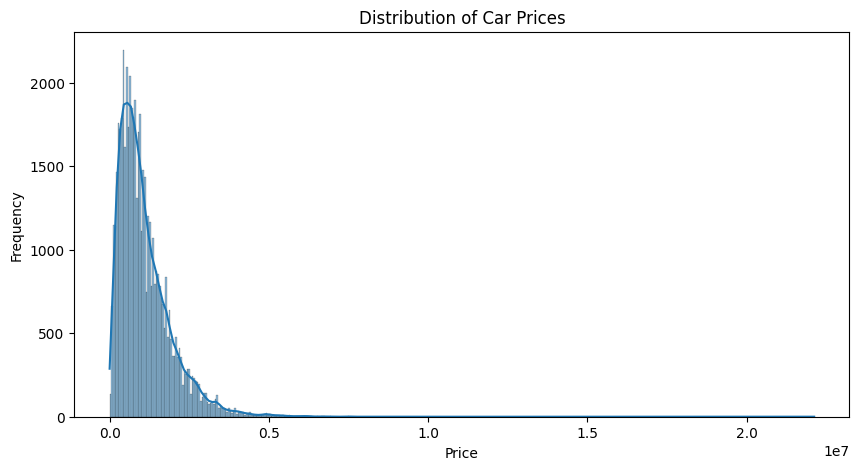

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(train["Price"], kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [ ]:
numerical_columns = train.select_dtypes(
    include=np.number
).columns

print(numerical_columns)

Index(['ID', 'Distance ', 'manufacture_year', 'Age of car',
       'engine_displacement', 'engine_power', 'Vroom Audit Rating',
       'door_count', 'seat_count', 'Price'],
      dtype='object')


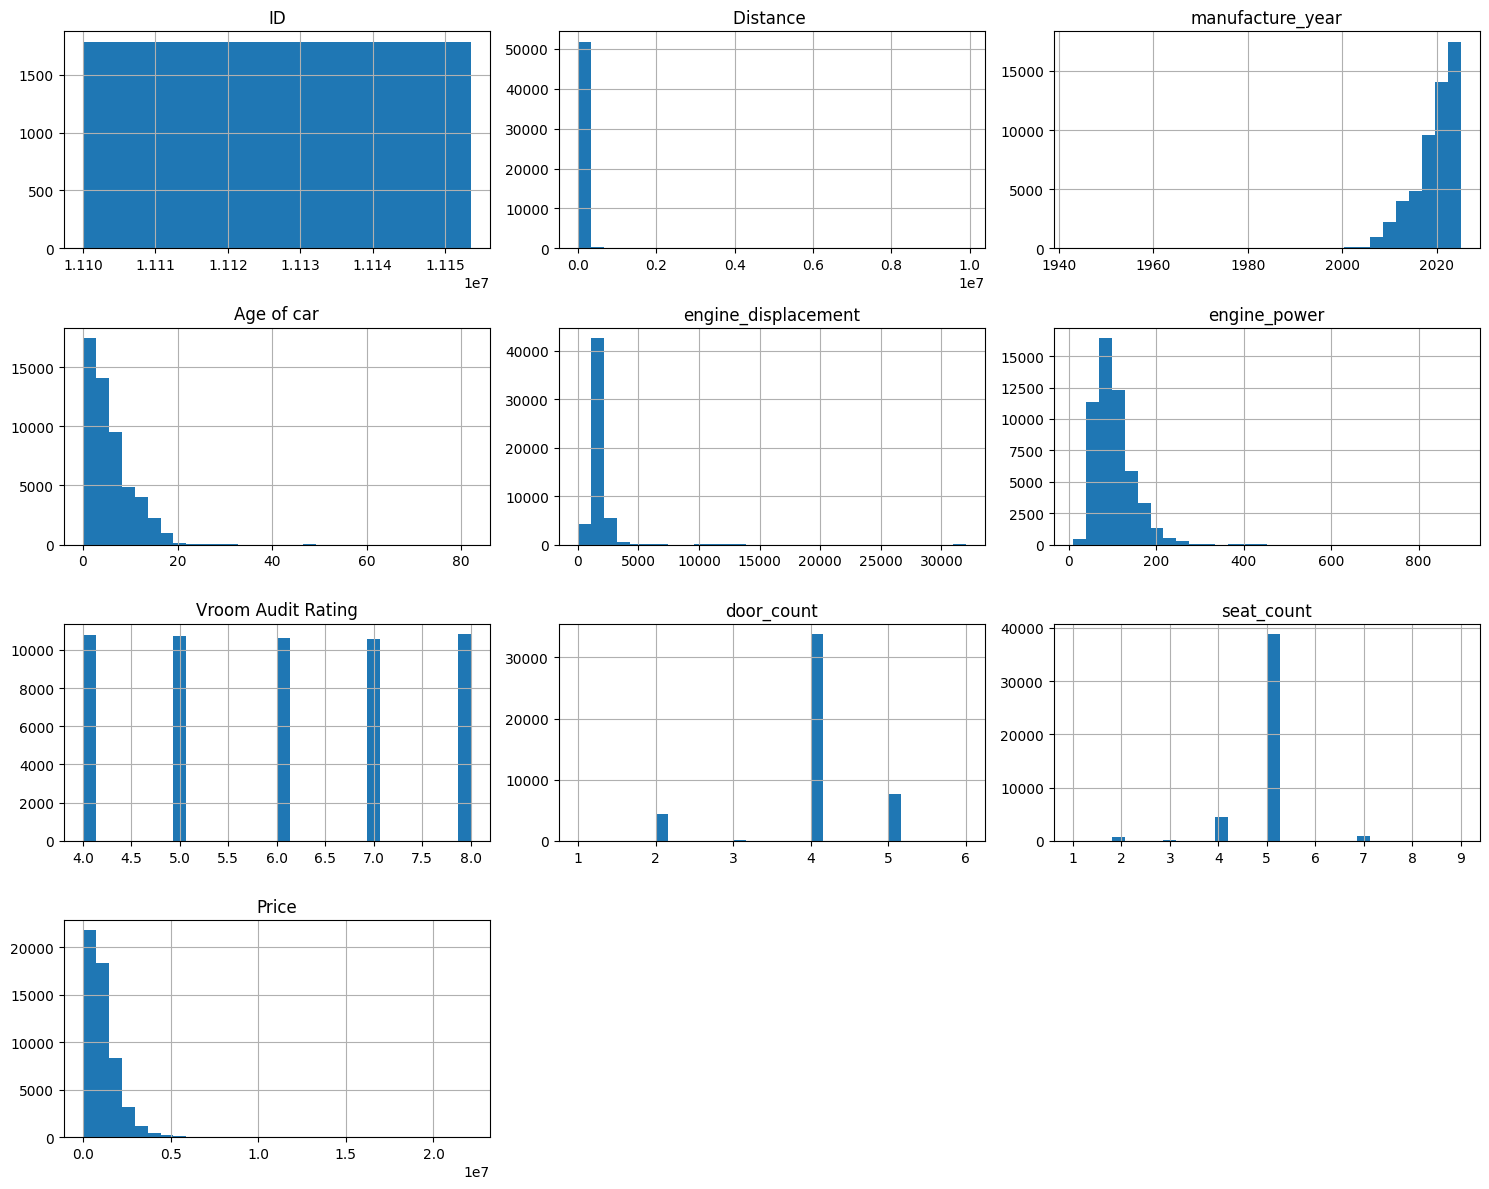

In [ ]:
train[numerical_columns].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

In [ ]:
categorical_columns = train.select_dtypes(
    include="object"
).columns

print(categorical_columns)

Index(['Maker', 'model', 'Location', 'Owner Type', 'body_type', 'transmission',
       'fuel_type'],
      dtype='object')


In [ ]:
train["Maker"].value_counts().head(20)

,count
Maker,
skoda,21563
toyota,7840
audi,7326
bmw,7178
nissan,5485
hyundai,2240
fiat,1845
maserati,38


In [ ]:
train["fuel_type"].value_counts()

,count
fuel_type,
diesel,27559
petrol,25956


In [ ]:
train["transmission"].value_counts()

,count
transmission,
man,36734
auto,16781


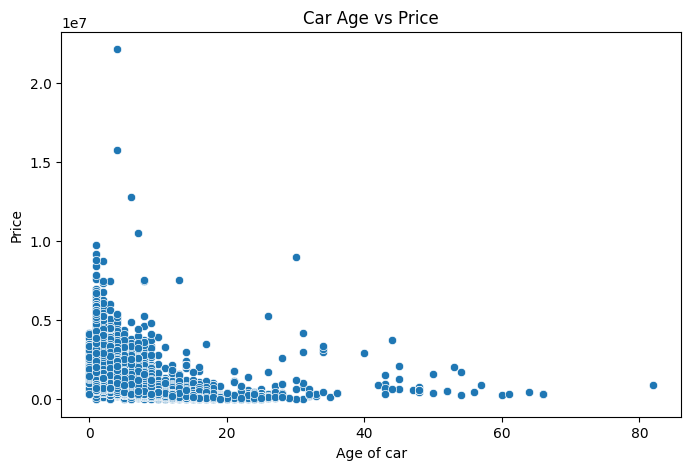

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train,
    x="Age of car",
    y="Price"
)

plt.title("Car Age vs Price")
plt.show()

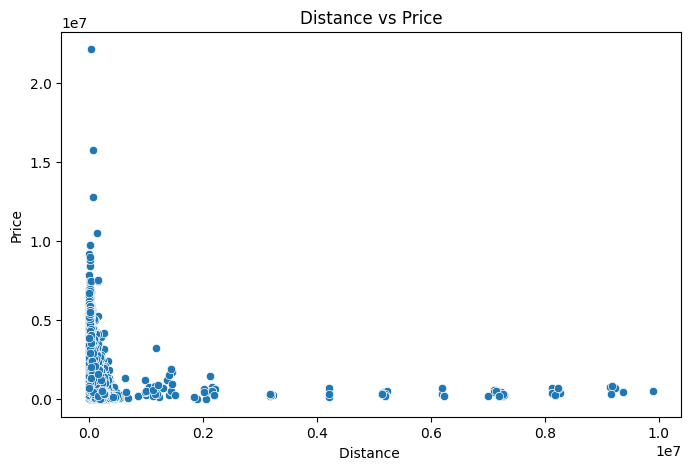

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train,
    x="Distance ",
    y="Price"
)

plt.title("Distance vs Price")
plt.show()

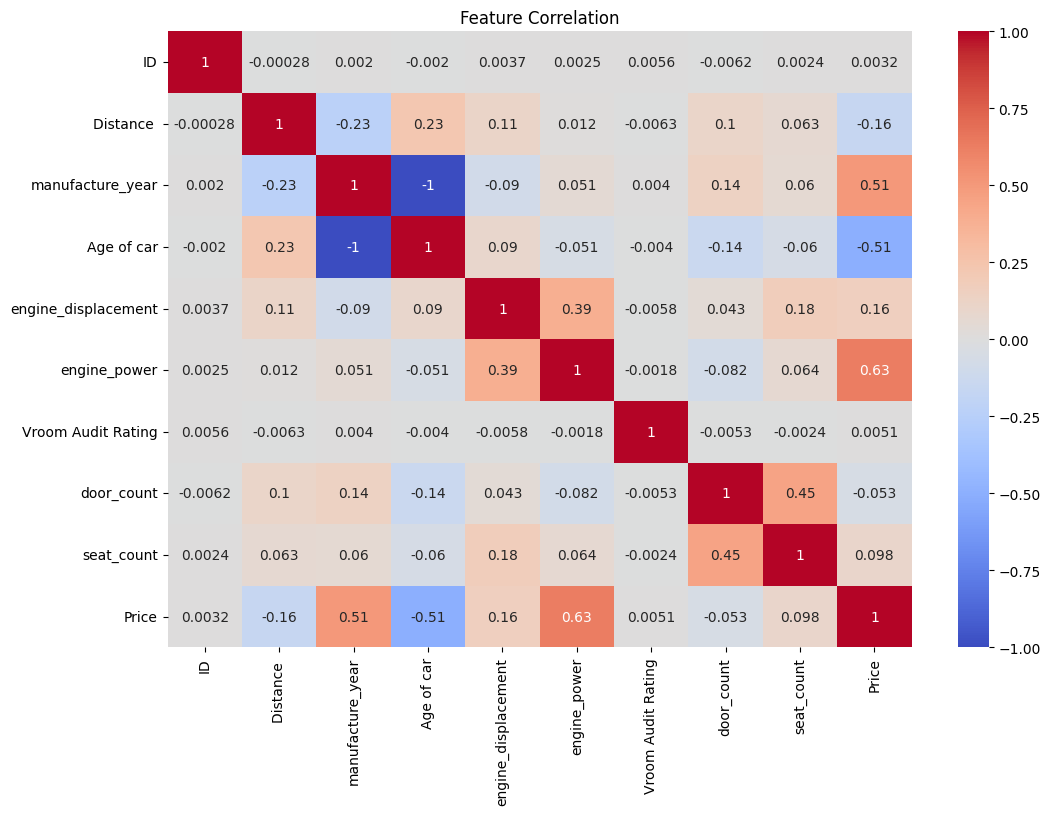

In [ ]:
plt.figure(figsize=(12, 8))

correlation = train.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

In [ ]:
numeric_cols = train.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    train[col] = train[col].fillna(
        train[col].median()
    )

In [ ]:
categorical_cols = train.select_dtypes(
    include="object"
).columns

for col in categorical_cols:
    train[col] = train[col].fillna(
        train[col].mode()[0]
    )

In [ ]:
train["manufacture_year"] = pd.to_numeric(
    train["manufacture_year"],
    errors="coerce"
)

In [ ]:
X = train.drop("Price", axis=1)

y = train["Price"]

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(42812, 16)
(10703, 16)


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

# Identify categorical columns for one-hot encoding
categorical_features = X.select_dtypes(include='object').columns

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform on X_train, then transform X_valid
X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_valid_encoded = encoder.transform(X_valid[categorical_features])

# Convert encoded features back to DataFrame
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(categorical_features), index=X_train.index)
X_valid_encoded_df = pd.DataFrame(X_valid_encoded, columns=encoder.get_feature_names_out(categorical_features), index=X_valid.index)

# Drop original categorical columns and concatenate encoded ones
X_train_processed = X_train.drop(columns=categorical_features).copy()
X_valid_processed = X_valid.drop(columns=categorical_features).copy()

X_train_processed = pd.concat([X_train_processed, X_train_encoded_df], axis=1)
X_valid_processed = pd.concat([X_valid_processed, X_valid_encoded_df], axis=1)

print("Shape of processed training data:", X_train_processed.shape)
print("Shape of processed validation data:", X_valid_processed.shape)

Shape of processed training data: (42812, 61)
Shape of processed validation data: (10703, 61)


In [ ]:
# Initialize and train the RandomForestRegressor model
model = RandomForestRegressor(random_state=42)
model.fit(X_train_processed, y_train)

# Make predictions on the validation set
predictions = model.predict(X_valid_processed)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_valid, predictions))
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_valid, predictions)
print(f"Mean Absolute Error (MAE): {mae}")

# Calculate R2 Score
r2 = r2_score(y_valid, predictions)
print(f"R-squared (R2) Score: {r2}")

Root Mean Squared Error (RMSE): 209800.67464160974
Mean Absolute Error (MAE): 108958.37787676352
R-squared (R2) Score: 0.9381502440983038


In [ ]:
rmse = np.sqrt(
    mean_squared_error(y_valid, predictions)
)

In [ ]:
import joblib

joblib.dump(
    model,
    "car_price_model.pkl"
)

['car_price_model.pkl']

In [ ]:
# Preprocess the test data using the same steps as the training data

# Impute missing numerical values in test data
numeric_cols_test = test.select_dtypes(include=np.number).columns
for col in numeric_cols_test:
    # Only fill if the column exists in test and was in train numeric columns
    if col in train.select_dtypes(include=np.number).columns:
        test[col] = test[col].fillna(train[col].median())

# Impute missing categorical values in test data
categorical_cols_test = test.select_dtypes(include='object').columns
for col in categorical_cols_test:
    # Only fill if the column exists in test and was in train categorical columns
    if col in train.select_dtypes(include='object').columns:
        test[col] = test[col].fillna(train[col].mode()[0])

# Convert 'manufacture_year' to numeric, coercing errors
test['manufacture_year'] = pd.to_numeric(test['manufacture_year'], errors='coerce')

# Impute any NaN values in 'manufacture_year' that might have resulted from coercion
test['manufacture_year'] = test['manufacture_year'].fillna(train['manufacture_year'].median())

# Apply the same OneHotEncoder fitted on the training data
# Identify categorical columns for one-hot encoding in test data
categorical_features_test = test.select_dtypes(include='object').columns

# Transform the categorical features in the test set using the already fitted encoder
X_test_encoded = encoder.transform(test[categorical_features_test])

# Convert encoded features back to DataFrame
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(categorical_features_test), index=test.index)

# Drop original categorical columns and concatenate encoded ones for test data
X_test_processed = test.drop(columns=categorical_features_test).copy()
X_test_processed = pd.concat([X_test_processed, X_test_encoded_df], axis=1)

# Align columns - crucial if test set has different categories or order
X_test_processed = X_test_processed.reindex(columns = X_train_processed.columns, fill_value=0)

print("Shape of processed test data:", X_test_processed.shape)

Shape of processed test data: (5615, 61)


In [ ]:
test_predictions = model.predict(X_test_processed)
print("Test predictions generated successfully.")
# Display first few predictions
print(test_predictions[:5])

Test predictions generated successfully.
[ 427844.4    1011754.7325 1351724.43   2338719.21   3074972.37  ]


In [ ]:
# Create a submission DataFrame
submission = pd.DataFrame({'ID': sample['ID'], 'Price': test_predictions})

# Display the first few rows of the submission file
print("Submission file head:")
print(submission.head())

Submission file head:
         ID         Price
0  21100001  4.278444e+05
1  21100002  1.011755e+06
2  21100003  1.351724e+06
3  21100004  2.338719e+06
4  21100005  3.074972e+06


In [ ]:
submission = pd.DataFrame({
    "ID": test["ID"],
    "Price": test_predictions
})

In [ ]:
submission.to_csv(
    "predictions.csv",
    index=False
)

In [ ]:
!pip install -r requirements.txt
streamlit run app/app.py

SyntaxError: invalid syntax (189182644.py, line 2)

In [ ]:
!pip install -q streamlit pyngrok joblib scikit-learn xgboost lightgbm

In [ ]:
!unzip -o "/content/Indian-Car-Price-Prediction-App (2).zip" -d "/content/"

Archive:  /content/Indian-Car-Price-Prediction-App (2).zip
   creating: /content/Indian-Car-Price-Prediction/app/
  inflating: /content/Indian-Car-Price-Prediction/app/app.py  
   creating: /content/Indian-Car-Price-Prediction/app/__pycache__/
  inflating: /content/Indian-Car-Price-Prediction/app/__pycache__/app.cpython-313.pyc  
  inflating: /content/Indian-Car-Price-Prediction/requirements.txt  
  inflating: /content/Indian-Car-Price-Prediction/README.md  


In [ ]:
!ls -R /content/Indian-Car-Price-Prediction

/content/Indian-Car-Price-Prediction:
app  data  models  README.md  requirements.txt

/content/Indian-Car-Price-Prediction/app:
app.py	__pycache__

/content/Indian-Car-Price-Prediction/app/__pycache__:
app.cpython-313.pyc

/content/Indian-Car-Price-Prediction/data:
Cap_Training_Data_2025.csv

/content/Indian-Car-Price-Prediction/models:
car_price_model.pkl  car_price_pipeline.pkl


In [ ]:
!mkdir -p /content/Indian-Car-Price-Prediction/data

In [ ]:
!cp "/content/Cap_Training_Data_2025.csv" \
"/content/Indian-Car-Price-Prediction/data/"

In [ ]:
!pip install -q streamlit pandas numpy joblib scikit-learn xgboost lightgbm pyngrok

In [ ]:
!streamlit run /content/Indian-Car-Price-Prediction-App /app.py \
    --server.port 8501 \
    --server.address 0.0.0.0

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Streamlit requires raw Python (.py) files, but the provided file has no extension.
For more information, please see https://docs.streamlit.io


In [ ]:
!mkdir -p /content/Indian-Car-Price-Prediction/models

In [ ]:
!mkdir -p /content/Indian-Car-Price-Prediction/models
!cp /content/car_price_model.pkl /content/Indian-Car-Price-Prediction/models/

In [ ]:
!curl ipv4.icanhazip.com

34.186.31.83


In [ ]:
!streamlit run /content/Indian-Car-Price-Prediction/app/app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-09-24 10:28:57.388 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.31.83:8501



  Stopping...
  Stopping...
^C


In [ ]:
!pip install pyngrok -q

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3JHgAROdj4Mc0OGIO3IuNn5G0Vl_6KDR9vMPRvh45xBsLJY2T")

In [ ]:
import os

# Launch Streamlit in the background
os.system("nohup streamlit run /content/Indian-Car-Price-Prediction/app/app.py --server.port 8501 &")

# Create the public ngrok tunnel
public_url = ngrok.connect(8501)
print("Streamlit App URL:", public_url)

Streamlit App URL: NgrokTunnel: "https://arise-krypton-gangly.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!unzip -o "/content/Indian-Car-Price-Prediction-App (2).zip" -d "/content/"

Archive:  /content/Indian-Car-Price-Prediction-App (2).zip
  inflating: /content/Indian-Car-Price-Prediction/app/app.py  
  inflating: /content/Indian-Car-Price-Prediction/app/__pycache__/app.cpython-313.pyc  
  inflating: /content/Indian-Car-Price-Prediction/requirements.txt  
  inflating: /content/Indian-Car-Price-Prediction/README.md  


In [ ]:
!ls -R /content/Indian-Car-Price-Prediction

/content/Indian-Car-Price-Prediction:
app  data  models  README.md  requirements.txt

/content/Indian-Car-Price-Prediction/app:
app.py	__pycache__

/content/Indian-Car-Price-Prediction/app/__pycache__:
app.cpython-313.pyc

/content/Indian-Car-Price-Prediction/data:
Cap_Training_Data_2025.csv

/content/Indian-Car-Price-Prediction/models:
car_price_model.pkl  car_price_pipeline.pkl


In [ ]:
!mkdir -p /content/Indian-Car-Price-Prediction/data

In [ ]:
!cp "/content/Cap_Training_Data_2025.csv" \
"/content/Indian-Car-Price-Prediction/data/"

In [ ]:
!pip install -q streamlit pandas numpy joblib scikit-learn xgboost lightgbm pyngrok

In [ ]:
!streamlit run /content/Indian-Car-Price-Prediction/app/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0




Aborted!


In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run /content/Indian-Car-Price-Prediction/app/app.py --server.port 8501 --server.address 0.0.0.0



2026-09-24 10:39:23.057 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.31.83:8501

  Stopping...
  Stopping...


In [ ]:
!pip install -q pyngrok

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3JHgAROdj4Mc0OGIO3IuNn5G0Vl_6KDR9vMPRvh45xBsLJY2T")

In [ ]:
import os
from pyngrok import ngrok

# Run Streamlit quietly in the background
os.system("nohup streamlit run /content/Indian-Car-Price-Prediction/app/app.py --server.port 8501 &")

# Create the public link
public_url = ngrok.connect(8501)
print("Click here to open your Streamlit app:", public_url)

Click here to open your Streamlit app: NgrokTunnel: "https://arise-krypton-gangly.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!mkdir -p /content/Indian-Car-Price-Prediction/models
!cp /content/car_price_model.pkl /content/Indian-Car-Price-Prediction/models/car_price_pipeline.pkl

In [ ]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor # Added import

# 1. Identify categorical features used during training
categorical_features = ['Maker', 'model', 'Location', 'Owner Type', 'body_type', 'transmission', 'fuel_type']

# 2. Build a preprocessor column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# Initialize the model (e.g., RandomForestRegressor)
model = RandomForestRegressor(random_state=42) # Added model initialization

# 3. Create a unified pipeline containing both preprocessing & model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# 4. Fit pipeline on raw training features (X_train)
pipeline.fit(X_train, y_train)

# 5. Save the complete pipeline to the Streamlit models folder
!mkdir -p /content/Indian-Car-Price-Prediction/models
joblib.dump(pipeline, '/content/Indian-Car-Price-Prediction/models/car_price_pipeline.pkl')

print("Pipeline created and saved successfully!")

In [ ]:
!cp "/content/Indian-Car-Price-Prediction/app/app.py" \
"/content/Indian-Car-Price-Prediction/app/app_backup.py"

In [ ]:
!cp "/content/app_fixed.py" \
"/content/Indian-Car-Price-Prediction/app/app.py"

In [ ]:
!ls -l /content/Indian-Car-Price-Prediction/app/

total 16
-rw-r--r-- 1 root root 10364 Sep 23 09:59 app.py
drwxr-xr-x 2 root root  4096 Sep 24 10:31 __pycache__


In [ ]:
!find /content/Indian-Car-Price-Prediction -maxdepth 3 -type f

/content/Indian-Car-Price-Prediction/data/Cap_Training_Data_2025.csv
/content/Indian-Car-Price-Prediction/requirements.txt
/content/Indian-Car-Price-Prediction/models/car_price_pipeline.pkl
/content/Indian-Car-Price-Prediction/models/car_price_model.pkl
/content/Indian-Car-Price-Prediction/README.md
/content/Indian-Car-Price-Prediction/app/app.py
/content/Indian-Car-Price-Prediction/app/__pycache__/app.cpython-313.pyc


In [ ]:
!mkdir -p /content/Indian-Car-Price-Prediction/models
!cp /content/car_price_model.pkl \
/content/Indian-Car-Price-Prediction/models/car_price_model.pkl

In [ ]:
!mkdir -p /content/Indian-Car-Price-Prediction/data

!cp /content/Cap_Training_Data_2025.csv \
/content/Indian-Car-Price-Prediction/data/Cap_Training_Data_2025.csv

In [ ]:
!pip install -q streamlit pyngrok joblib pandas numpy scikit-learn xgboost lightgbm

In [ ]:
!pkill -f streamlit || true

^C


In [ ]:
import subprocess

subprocess.Popen(
    [
        "streamlit",
        "run",
        "/content/Indian-Car-Price-Prediction/app/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
    ],
    stdout=open("/content/streamlit.log", "w"),
    stderr=subprocess.STDOUT,
)

print("Streamlit started")

Streamlit started


In [ ]:
!cat /content/streamlit.log



2026-09-24 10:44:50.683 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.31.83:8501

  Stopping...


In [ ]:
!find /content/Indian-Car-Price-Prediction -type f -name "*.py"

/content/Indian-Car-Price-Prediction/app/app.py
/content/Indian-Car-Price-Prediction/app/app_backup.py


In [ ]:
from pyngrok import ngrok

ngrok.kill()

url = ngrok.connect(8501)

print("YOUR STREAMLIT APP:")
print(url)

YOUR STREAMLIT APP:
NgrokTunnel: "https://arise-krypton-gangly.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run /content/Indian-Car-Price-Prediction/app/app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &

In [ ]:
!sleep 3
!cat /content/streamlit.log



2026-09-24 10:50:35.038 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.31.83:8501



In [ ]:
!find /content/Indian-Car-Price-Prediction -type f -name "*.py"

/content/Indian-Car-Price-Prediction/app/app.py
/content/Indian-Car-Price-Prediction/app/app_backup.py


In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run /content/Indian-Car-Price-Prediction/app/app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &

In [ ]:
!pip install -q pyngrok

In [ ]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)
print("YOUR APP LINK:")
print(public_url)

YOUR APP LINK:
NgrokTunnel: "https://arise-krypton-gangly.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
import pandas as pd

pred = pd.read_csv("/content/predictions.csv")

print("Shape:", pred.shape)
print("Columns:", pred.columns.tolist())
print(pred.head())
print(pred.isnull().sum())

Shape: (5615, 2)
Columns: ['ID', 'Price']
         ID         Price
0  21100001  4.278444e+05
1  21100002  1.011755e+06
2  21100003  1.351724e+06
3  21100004  2.338719e+06
4  21100005  3.074972e+06
ID       0
Price    0
dtype: int64


In [ ]:
import os

print(os.path.exists(
    "/content/Indian-Car-Price-Prediction/models/car_price_model.pkl"
))

True


In [ ]:
!mkdir -p /content/Final-Car-Price-Project/app
!mkdir -p /content/Final-Car-Price-Project/models
!mkdir -p /content/Final-Car-Price-Project/data
!mkdir -p /content/Final-Car-Price-Project/outputs

In [ ]:
!cp "/content/Indian-Car-Price-Prediction/app/app.py" \
"/content/Final-Car-Price-Project/app/app.py"

!cp "/content/Indian-Car-Price-Prediction/models/car_price_model.pkl" \
"/content/Final-Car-Price-Project/models/car_price_model.pkl"

!cp "/content/Cap_Training_Data_2025.csv" \
"/content/Final-Car-Price-Project/data/Cap_Training_Data_2025.csv"

!cp "/content/Cap_Test_Data_2025.csv" \
"/content/Final-Car-Price-Project/data/Cap_Test_Data_2025.csv"

!cp "/content/predictions.csv" \
"/content/Final-Car-Price-Project/outputs/predictions.csv"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir -p "/content/drive/MyDrive/Indian-Car-Price-Prediction/app"
!mkdir -p "/content/drive/MyDrive/Indian-Car-Price-Prediction/models"
!mkdir -p "/content/drive/MyDrive/Indian-Car-Price-Prediction/data"
!mkdir -p "/content/drive/MyDrive/Indian-Car-Price-Prediction/outputs"

In [ ]:
!cp -r "/content/drive/MyDrive/Indian-Car-Price-Prediction" "/content/"

In [ ]:
!zip -r /content/Indian-Car-Price-Prediction.zip /content/Indian-Car-Price-Prediction

  adding: content/Indian-Car-Price-Prediction/ (stored 0%)
  adding: content/Indian-Car-Price-Prediction/outputs/ (stored 0%)
  adding: content/Indian-Car-Price-Prediction/data/ (stored 0%)
  adding: content/Indian-Car-Price-Prediction/data/Cap_Training_Data_2025.csv (deflated 80%)
  adding: content/Indian-Car-Price-Prediction/requirements.txt (deflated 5%)
  adding: content/Indian-Car-Price-Prediction/models/ (stored 0%)
  adding: content/Indian-Car-Price-Prediction/models/car_price_pipeline.pkl (deflated 81%)
  adding: content/Indian-Car-Price-Prediction/models/car_price_model.pkl (deflated 81%)
  adding: content/Indian-Car-Price-Prediction/README.md (deflated 44%)
  adding: content/Indian-Car-Price-Prediction/app/ (stored 0%)
  adding: content/Indian-Car-Price-Prediction/app/app.py (deflated 71%)
  adding: content/Indian-Car-Price-Prediction/app/app_backup.py (deflated 71%)
  adding: content/Indian-Car-Price-Prediction/app/__pycache__/ (stored 0%)
  adding: content/Indian-Car-Price-